In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [32]:
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
df = heart_disease.data.original
df.dropna(inplace=True)
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numeric = [col for col in df.columns if col not in categorical and col != 'num']
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [33]:
df['num'].value_counts()

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

In [34]:
df['target'] = (df['num'] > 0).astype(int)
df['target'].value_counts()

target
0    160
1    137
Name: count, dtype: int64

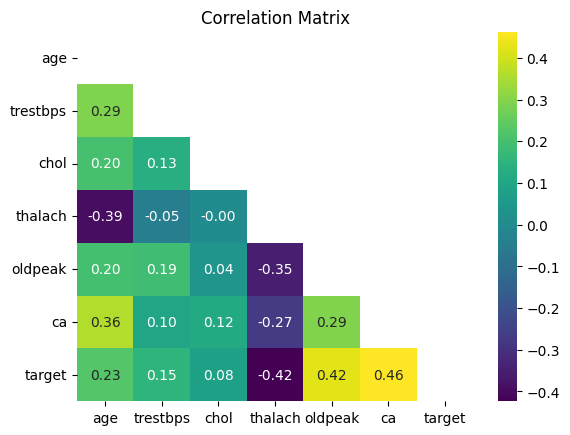

In [35]:
corr_matrix = df[numeric + ['target']].corr()
mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt='.2f', mask=mask)
plt.title('Correlation Matrix')
plt.show()

In [36]:
wanted = list(corr_matrix[abs(corr_matrix['target']) > 0.30].index)
wanted

['thalach', 'oldpeak', 'ca', 'target']

In [37]:
X = df[numeric]
y = df['target']

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X)
pca_coords = pd.DataFrame(data=pca_coords, columns=['pca1', 'pca2'])

tsne = TSNE(n_components=2)
tsne_coords = tsne.fit_transform(X)
tsne_coords = pd.DataFrame(data=tsne_coords, columns=['tsne1', 'tsne2'])

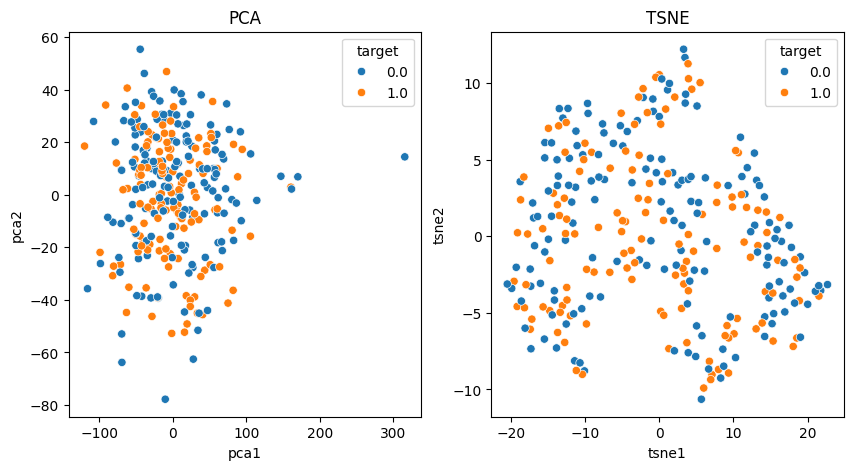

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.scatterplot(data=pca_coords, x='pca1', y='pca2', hue=y, ax=ax[0])
ax[0].set_title('PCA')

sns.scatterplot(data=tsne_coords, x='tsne1', y='tsne2', hue=y, ax=ax[1])
ax[1].set_title('TSNE')

plt.show()

In [43]:
X = df[numeric + categorical]
y = df['target']

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

tree = Pipeline([("prep", preprocess), ("clf", DecisionTreeClassifier(random_state=42))])
svm = Pipeline([("prep", preprocess), ("clf", SVC(probability=True, random_state=42))])
knn = Pipeline([("prep", preprocess), ("clf", KNeighborsClassifier(n_neighbors=5))])

models = {"DecisionTree": tree, "SVM": svm, "KNN": knn}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print('=======================================================')
    print(f"                     [ {name} ]")
    print(classification_report(y_test, y_pred, target_names=["no disease", "disease"]))
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")
    cm = confusion_matrix(y_test, y_pred)
    print(f"            pred 0   pred 1")
    print(f"true 0     {cm[0, 0]:>6}   {cm[0, 1]:>6}")
    print(f"true 1     {cm[1, 0]:>6}   {cm[1, 1]:>6}\n")

                     [ DecisionTree ]
              precision    recall  f1-score   support

  no disease       0.65      0.69      0.67        32
     disease       0.62      0.57      0.59        28

    accuracy                           0.63        60
   macro avg       0.63      0.63      0.63        60
weighted avg       0.63      0.63      0.63        60

ROC AUC: 0.629
            pred 0   pred 1
true 0         22       10
true 1         12       16

                     [ SVM ]
              precision    recall  f1-score   support

  no disease       0.83      0.91      0.87        32
     disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

ROC AUC: 0.960
            pred 0   pred 1
true 0         29        3
true 1          6       22

                     [ KNN ]
              precision    recall  f1-score   support
